# Experiment No. 4: Markov Decision Process and Bayesian Learning

## Practical Implementation
This notebook contains practical implementations of:
1. **Markov Decision Process (MDP)** - Grid world with value and policy iteration
2. **Bayesian Learning** - Coin flip, Gaussian estimation, and classification examples

## Part 1: Markov Decision Process (MDP) - Practical Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import pandas as pd
from scipy.stats import beta, norm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
class MDP:
    """Implementation of a Markov Decision Process"""
    
    def __init__(self, states: List[int], actions: List[str], 
                 transition_prob: Dict, rewards: Dict, gamma: float = 0.9):
        """
        Initialize MDP
        
        Args:
            states: List of state identifiers
            actions: List of action identifiers
            transition_prob: Dictionary P(s'|s,a)
            rewards: Dictionary R(s,a,s')
            gamma: Discount factor
        """
        self.states = states
        self.actions = actions
        self.transition_prob = transition_prob
        self.rewards = rewards
        self.gamma = gamma
        self.values = {s: 0 for s in states}
        self.policy = {s: actions[0] for s in states}
    
    def get_next_states(self, state: int, action: str) -> List[int]:
        """Get possible next states for a given state-action pair"""
        return list(self.transition_prob[state][action].keys())
    
    def get_transition_prob(self, state: int, action: str, next_state: int) -> float:
        """Get transition probability P(s'|s,a)"""
        return self.transition_prob[state][action].get(next_state, 0)
    
    def get_reward(self, state: int, action: str, next_state: int) -> float:
        """Get reward R(s,a,s')"""
        return self.rewards[state][action].get(next_state, 0)

In [3]:
def create_grid_world_mdp() -> MDP:
    """Create a simple 3x3 grid world MDP"""
    
    # States: 0-8 representing 3x3 grid
    states = list(range(9))
    actions = ['up', 'down', 'left', 'right']
    
    # Transition probabilities (with some stochasticity)
    transition_prob = {}
    rewards = {}
    
    for state in states:
        row, col = state // 3, state % 3
        transition_prob[state] = {}
        rewards[state] = {}
        
        for action in actions:
            transition_prob[state][action] = {}
            rewards[state][action] = {}
            
            # Calculate next state position
            if action == 'up':
                next_row, next_col = max(0, row-1), col
            elif action == 'down':
                next_row, next_col = min(2, row+1), col
            elif action == 'left':
                next_row, next_col = row, max(0, col-1)
            else:  # right
                next_row, next_col = row, min(2, col+1)
            
            next_state = next_row * 3 + next_col
            
            # 80% chance to move as intended, 20% chance to stay
            transition_prob[state][action][next_state] = 0.8
            transition_prob[state][action][state] = 0.2
            
            # Reward: -1 for each move, +10 for reaching goal (state 8), -10 for obstacle (state 4)
            if next_state == 8:  # Goal
                rewards[state][action][next_state] = 10
            elif next_state == 4:  # Obstacle
                rewards[state][action][next_state] = -10
            else:
                rewards[state][action][next_state] = -1
            
            rewards[state][action][state] = -1  # Stay penalty
    
    return MDP(states, actions, transition_prob, rewards, gamma=0.9)

In [4]:
# Create and visualize the grid world MDP
mdp = create_grid_world_mdp()
print(f"States: {mdp.states}")
print(f"Actions: {mdp.actions}")
print(f"Discount factor (gamma): {mdp.gamma}")
print("\nGrid World Layout:")
print("0 1 2")
print("3 X 5")
print("6 7 G")
print("\nWhere X = obstacle (state 4), G = goal (state 8)")

States: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Actions: ['up', 'down', 'left', 'right']
Discount factor (gamma): 0.9

Grid World Layout:
0 1 2
3 X 5
6 7 G

Where X = obstacle (state 4), G = goal (state 8)


## Value Iteration Algorithm Implementation

In [9]:
def value_iteration(mdp: MDP, theta: float = 1e-6, max_iterations: int = 1000) -> Tuple[Dict, Dict]:
    """
    Value Iteration Algorithm
    
    Args:
        mdp: Markov Decision Process
        theta: Convergence threshold
        max_iterations: Maximum number of iterations
    
    Returns:
        values: Optimal state values
        policy: Optimal policy
    """
    values = {s: 0 for s in mdp.states}
    iteration = 0
    convergence_history = []
    
    while iteration < max_iterations:
        delta = 0
        new_values = values.copy()
        
        for state in mdp.states:
            if state == 8:  # Terminal state (goal)
                new_values[state] = 0
                continue
            
            action_values = []
            for action in mdp.actions:
                action_value = 0
                for next_state in mdp.get_next_states(state, action):
                    prob = mdp.get_transition_prob(state, action, next_state)
                    reward = mdp.get_reward(state, action, next_state)
                    action_value += prob * (reward + mdp.gamma * values[next_state])
                action_values.append(action_value)
            
            new_values[state] = max(action_values)
            delta = max(delta, abs(new_values[state] - values[state]))
        
        values = new_values
        convergence_history.append(delta)
        iteration += 1
        
        if delta < theta:
            break
    
    # Extract optimal policy
    policy = {}
    for state in mdp.states:
        if state == 8:  # Terminal state
            policy[state] = None
            continue
        
        action_values = {}
        for action in mdp.actions:
            action_value = 0
            for next_state in mdp.get_next_states(state, action):
                prob = mdp.get_transition_prob(state, action, next_state)
                reward = mdp.get_reward(state, action, next_state)
                action_value += prob * (reward + mdp.gamma * values[next_state])
            action_values[action] = action_value
        
        policy[state] = max(action_values, key=action_values.get)
    
    return values, policy, convergence_history

In [11]:
# Run value iteration
optimal_values, optimal_policy, convergence = value_iteration(mdp)

print(f"Value iteration converged in {len(convergence)} iterations")
print(f"Final delta: {convergence[-1]:.6f}")

# Display results
print("\nOptimal Values:")
values_grid = np.array([[optimal_values[i*3 + j] for j in range(3)] for i in range(3)])
print(values_grid.round(2))

print("\nOptimal Policy:")
policy_grid = np.array([[optimal_policy[i*3 + j] for j in range(3)] for i in range(3)])
print(policy_grid)

Value iteration converged in 17 iterations
Final delta: 0.000000

Optimal Values:
[[3.21 5.04 7.13]
 [5.04 7.13 9.51]
 [7.13 9.51 0.  ]]

Optimal Policy:
[['down' 'right' 'down']
 ['down' 'down' 'down']
 ['right' 'right' None]]


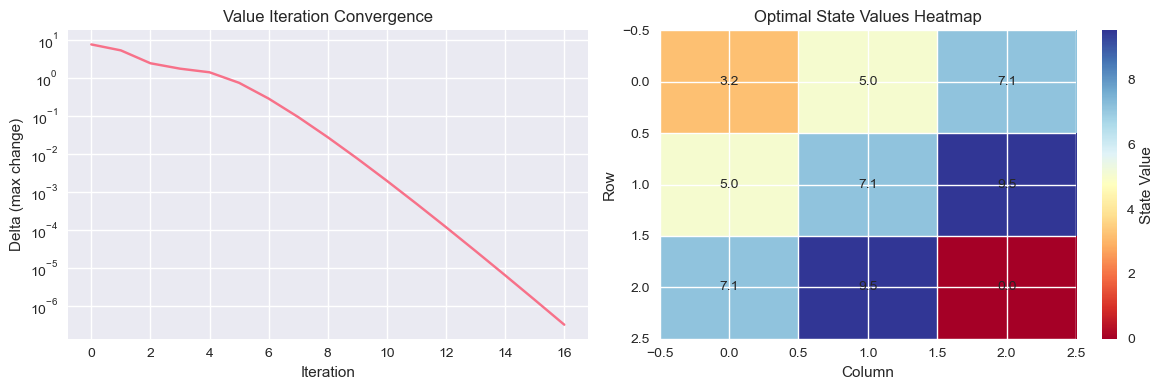

In [13]:
# Visualize convergence
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(convergence)
plt.xlabel('Iteration')
plt.ylabel('Delta (max change)')
plt.title('Value Iteration Convergence')
plt.yscale('log')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.imshow(values_grid, cmap='RdYlBu', aspect='auto')
plt.colorbar(label='State Value')
plt.title('Optimal State Values Heatmap')
plt.xlabel('Column')
plt.ylabel('Row')
for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{values_grid[i, j]:.1f}', ha='center', va='center')

plt.tight_layout()
plt.show()

## Policy Iteration Algorithm Implementation

In [15]:
def policy_evaluation(mdp: MDP, policy: Dict, theta: float = 1e-6) -> Dict:
    """Evaluate a given policy using iterative policy evaluation"""
    values = {s: 0 for s in mdp.states}
    
    while True:
        delta = 0
        for state in mdp.states:
            if state == 8:  # Terminal state
                continue
            
            action = policy[state]
            if action is None:
                continue
            
            new_value = 0
            for next_state in mdp.get_next_states(state, action):
                prob = mdp.get_transition_prob(state, action, next_state)
                reward = mdp.get_reward(state, action, next_state)
                new_value += prob * (reward + mdp.gamma * values[next_state])
            
            delta = max(delta, abs(new_value - values[state]))
            values[state] = new_value
        
        if delta < theta:
            break
    
    return values

def policy_improvement(mdp: MDP, values: Dict) -> Dict:
    """Improve policy based on current values"""
    new_policy = {}
    
    for state in mdp.states:
        if state == 8:  # Terminal state
            new_policy[state] = None
            continue
        
        action_values = {}
        for action in mdp.actions:
            action_value = 0
            for next_state in mdp.get_next_states(state, action):
                prob = mdp.get_transition_prob(state, action, next_state)
                reward = mdp.get_reward(state, action, next_state)
                action_value += prob * (reward + mdp.gamma * values[next_state])
            action_values[action] = action_value
        
        new_policy[state] = max(action_values, key=action_values.get)
    
    return new_policy

def policy_iteration(mdp: MDP, max_iterations: int = 100) -> Tuple[Dict, Dict, int]:
    """Policy Iteration Algorithm"""
    # Initialize random policy
    policy = {s: mdp.actions[0] for s in mdp.states if s != 8}
    policy[8] = None  # Terminal state
    
    for iteration in range(max_iterations):
        # Policy evaluation
        values = policy_evaluation(mdp, policy)
        
        # Policy improvement
        new_policy = policy_improvement(mdp, values)
        
        # Check for convergence
        if all(policy[s] == new_policy[s] for s in mdp.states):
            return values, new_policy, iteration + 1
        
        policy = new_policy
    
    return values, policy, max_iterations

In [17]:
# Run policy iteration
pi_values, pi_policy, pi_iterations = policy_iteration(mdp)

print(f"Policy iteration converged in {pi_iterations} iterations")

# Display results
print("\nPolicy Iteration Values:")
pi_values_grid = np.array([[pi_values[i*3 + j] for j in range(3)] for i in range(3)])
print(pi_values_grid.round(2))

print("\nPolicy Iteration Policy:")
pi_policy_grid = np.array([[pi_policy[i*3 + j] for j in range(3)] for i in range(3)])
print(pi_policy_grid)

# Compare with value iteration
print("\nComparison:")
print(f"Value iteration iterations: {len(convergence)}")
print(f"Policy iteration iterations: {pi_iterations}")
print(f"Policies match: {all(optimal_policy[s] == pi_policy[s] for s in mdp.states)}")

Policy iteration converged in 5 iterations

Policy Iteration Values:
[[3.21 5.04 7.13]
 [5.04 7.13 9.51]
 [7.13 9.51 0.  ]]

Policy Iteration Policy:
[['down' 'right' 'down']
 ['down' 'down' 'down']
 ['right' 'right' None]]

Comparison:
Value iteration iterations: 17
Policy iteration iterations: 5
Policies match: True


## Part 2: Bayesian Learning - Practical Implementation

In [19]:
class BayesianLearning:
    """Implementation of Bayesian Learning algorithms"""
    
    def __init__(self):
        self.prior_params = {}
        self.posterior_params = {}
        self.data_history = []
    
    def beta_binomial_update(self, alpha: float, beta: float, 
                            successes: int, failures: int) -> Tuple[float, float]:
        """
        Update Beta-Binomial conjugate prior
        
        Args:
            alpha, beta: Prior parameters
            successes, failures: Observed data
        
        Returns:
            Posterior parameters (alpha_post, beta_post)
        """
        alpha_post = alpha + successes
        beta_post = beta + failures
        return alpha_post, beta_post
    
    def gaussian_update(self, mu_0: float, sigma_0_sq: float, 
                       data: List[float], sigma_sq: float) -> Tuple[float, float]:
        """
        Update Gaussian conjugate prior
        
        Args:
            mu_0, sigma_0_sq: Prior mean and variance
            data: Observed data
            sigma_sq: Known likelihood variance
        
        Returns:
            Posterior mean and variance
        """
        n = len(data)
        x_bar = np.mean(data)
        
        # Posterior precision = prior precision + data precision
        precision_post = 1/sigma_0_sq + n/sigma_sq
        sigma_post_sq = 1/precision_post
        
        # Posterior mean = weighted average of prior mean and sample mean
        mu_post = sigma_post_sq * (mu_0/sigma_0_sq + n*x_bar/sigma_sq)
        
        return mu_post, sigma_post_sq
    
    def bayesian_inference(self, prior_dist, likelihood_func, data, 
                         param_range: np.ndarray) -> np.ndarray:
        """
        General Bayesian inference using numerical methods
        
        Args:
            prior_dist: Prior distribution function
            likelihood_func: Likelihood function
            data: Observed data
            param_range: Range of parameters to evaluate
        
        Returns:
            Posterior distribution
        """
        # Calculate prior
        prior = prior_dist(param_range)
        
        # Calculate likelihood
        likelihood = np.array([likelihood_func(param, data) for param in param_range])
        
        # Calculate posterior (unnormalized)
        posterior = prior * likelihood
        
        # Normalize
        posterior = posterior / np.trapz(posterior, param_range)
        
        return posterior

## Beta-Binomial Example: Coin Flip Problem

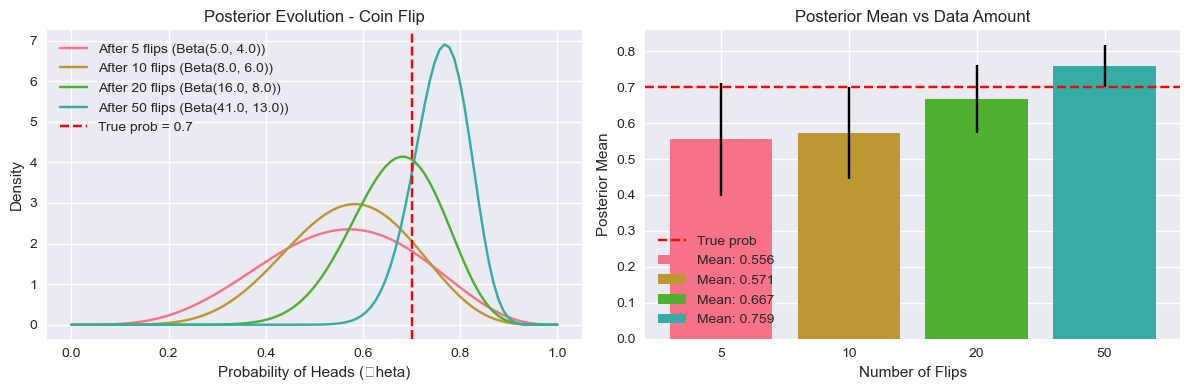

In [21]:
def coin_flip_experiment():
    """Demonstrate Bayesian learning with coin flips"""
    
    # Initialize Bayesian learner
    bl = BayesianLearning()
    
    # Prior: Beta(2, 2) - uniform belief about coin fairness
    alpha_prior, beta_prior = 2, 2
    
    # Simulate coin flips (true probability = 0.7)
    true_prob = 0.7
    np.random.seed(42)
    flips = np.random.binomial(1, true_prob, 50)
    
    # Update beliefs incrementally
    theta_range = np.linspace(0, 1, 100)
    posteriors = []
    
    # Store posterior at different stages
    stages = [0, 5, 10, 20, 50]
    current_alpha, current_beta = alpha_prior, beta_prior
    
    for i, flip in enumerate(flips, 1):
        if flip == 1:  # Heads
            current_alpha, current_beta = bl.beta_binomial_update(
                current_alpha, current_beta, 1, 0)
        else:  # Tails
            current_alpha, current_beta = bl.beta_binomial_update(
                current_alpha, current_beta, 0, 1)
        
        if i in stages:
            posterior = beta.pdf(theta_range, current_alpha, current_beta)
            posteriors.append((i, current_alpha, current_beta, posterior))
    
    return theta_range, posteriors, true_prob

# Run experiment
theta_range, posteriors, true_prob = coin_flip_experiment()

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for i, alpha, beta, posterior in posteriors:
    plt.plot(theta_range, posterior, label=f'After {i} flips (Beta({alpha:.1f}, {beta:.1f}))')
plt.axvline(true_prob, color='red', linestyle='--', label=f'True prob = {true_prob}')
plt.xlabel('Probability of Heads (\theta)')
plt.ylabel('Density')
plt.title('Posterior Evolution - Coin Flip')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Show posterior statistics
for i, alpha, beta, _ in posteriors:
    mean = alpha / (alpha + beta)
    mode = (alpha - 1) / (alpha + beta - 2) if alpha + beta > 2 else 0.5
    variance = (alpha * beta) / ((alpha + beta)**2 * (alpha + beta + 1))
    plt.bar(str(i), mean, yerr=np.sqrt(variance), capsize=5, 
            label=f'Mean: {mean:.3f}')

plt.axhline(true_prob, color='red', linestyle='--', label='True prob')
plt.xlabel('Number of Flips')
plt.ylabel('Posterior Mean')
plt.title('Posterior Mean vs Data Amount')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Gaussian Example: Estimating Mean

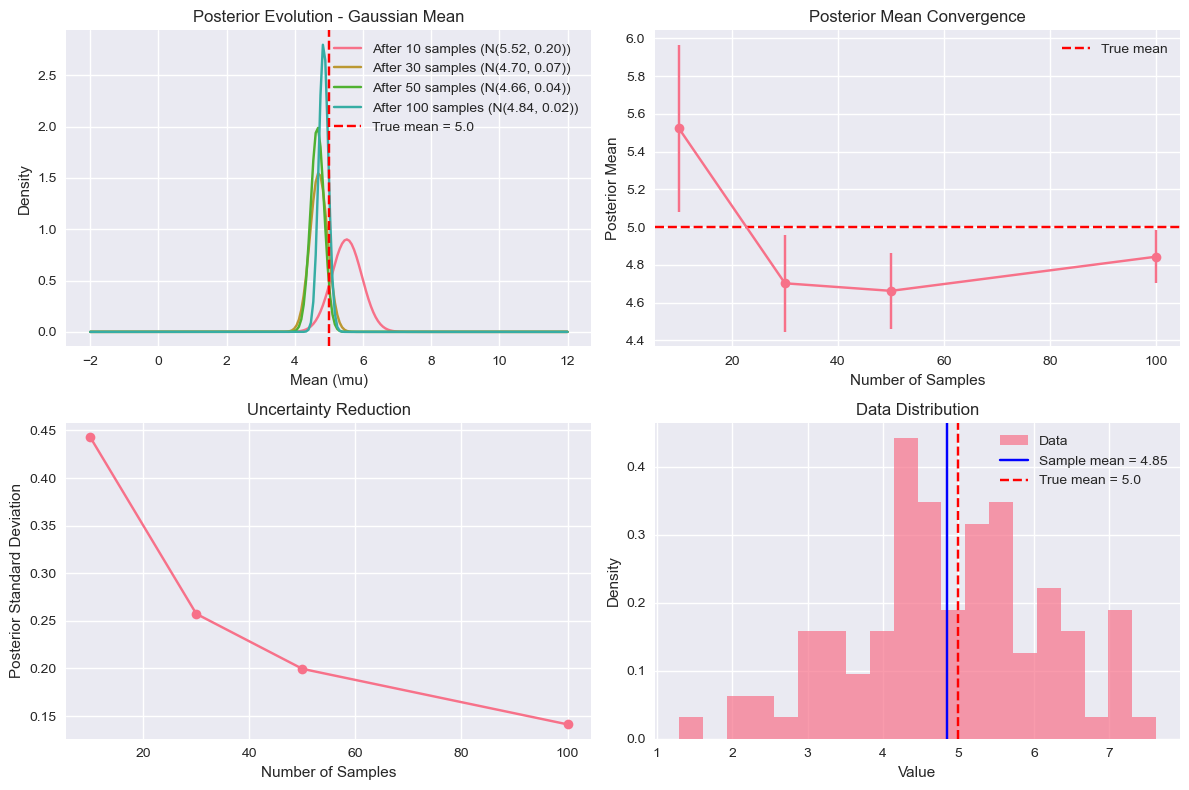

In [23]:
def gaussian_mean_estimation():
    """Demonstrate Bayesian learning for Gaussian mean estimation"""
    
    # True parameters
    true_mean = 5.0
    true_var = 2.0
    
    # Prior: N(0, 10) - vague prior
    mu_0, sigma_0_sq = 0, 10
    
    # Generate data
    np.random.seed(42)
    data = np.random.normal(true_mean, np.sqrt(true_var), 100)
    
    # Update beliefs incrementally
    bl = BayesianLearning()
    posteriors = []
    mu_range = np.linspace(-2, 12, 200)
    
    stages = [0, 10, 30, 50, 100]
    for i in range(1, len(data) + 1):
        if i in stages:
            mu_post, sigma_post_sq = bl.gaussian_update(
                mu_0, sigma_0_sq, data[:i], true_var)
            
            posterior = norm.pdf(mu_range, mu_post, np.sqrt(sigma_post_sq))
            posteriors.append((i, mu_post, sigma_post_sq, posterior))
    
    return mu_range, posteriors, true_mean, data

# Run experiment
mu_range, gauss_posteriors, true_mean, data = gaussian_mean_estimation()

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
for i, mu, sigma_sq, posterior in gauss_posteriors:
    plt.plot(mu_range, posterior, label=f'After {i} samples (N({mu:.2f}, {sigma_sq:.2f}))')
plt.axvline(true_mean, color='red', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Mean (\mu)')
plt.ylabel('Density')
plt.title('Posterior Evolution - Gaussian Mean')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
# Show posterior statistics
means = [p[1] for p in gauss_posteriors]
stds = [np.sqrt(p[2]) for p in gauss_posteriors]
sample_sizes = [p[0] for p in gauss_posteriors]

plt.errorbar(sample_sizes, means, yerr=stds, capsize=5, marker='o', linestyle='-')
plt.axhline(true_mean, color='red', linestyle='--', label='True mean')
plt.xlabel('Number of Samples')
plt.ylabel('Posterior Mean')
plt.title('Posterior Mean Convergence')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
# Show uncertainty reduction
plt.plot(sample_sizes, stds, marker='o', linestyle='-')
plt.xlabel('Number of Samples')
plt.ylabel('Posterior Standard Deviation')
plt.title('Uncertainty Reduction')
plt.grid(True)

plt.subplot(2, 2, 4)
# Show data histogram
plt.hist(data, bins=20, density=True, alpha=0.7, label='Data')
plt.axvline(np.mean(data), color='blue', linestyle='-', label=f'Sample mean = {np.mean(data):.2f}')
plt.axvline(true_mean, color='red', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Data Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Bayesian Classification

In [25]:
class BayesianClassifier:
    """Simple Bayesian classifier with Gaussian likelihood"""
    
    def __init__(self):
        self.class_priors = {}
        self.class_params = {}  # {class: {'mean': float, 'var': float}}
        self.classes = []
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        """Train the Bayesian classifier"""
        self.classes = np.unique(y)
        
        # Calculate class priors
        total_samples = len(y)
        for c in self.classes:
            self.class_priors[c] = np.sum(y == c) / total_samples
        
        # Calculate class parameters (mean and variance)
        for c in self.classes:
            class_data = X[y == c]
            self.class_params[c] = {
                'mean': np.mean(class_data),
                'var': np.var(class_data)
            }
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict class probabilities"""
        n_samples = len(X)
        n_classes = len(self.classes)
        probabilities = np.zeros((n_samples, n_classes))
        
        for i, x in enumerate(X):
            for j, c in enumerate(self.classes):
                # Prior probability
                prior = self.class_priors[c]
                
                # Likelihood (Gaussian)
                mean = self.class_params[c]['mean']
                var = self.class_params[c]['var']
                likelihood = norm.pdf(x, mean, np.sqrt(var))
                
                # Posterior (unnormalized)
                probabilities[i, j] = prior * likelihood
            
            # Normalize
            probabilities[i] /= np.sum(probabilities[i])
        
        return probabilities
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return self.classes[np.argmax(probabilities, axis=1)]

Classification Accuracy: 0.980
Class Priors: {0: 0.6666666666666666, 1: 0.3333333333333333}
Class Parameters: {0: {'mean': 1.8961534826059059, 'var': 0.8165221946938584}, 1: {'mean': 5.941068649995864, 'var': 2.2734977760914505}}


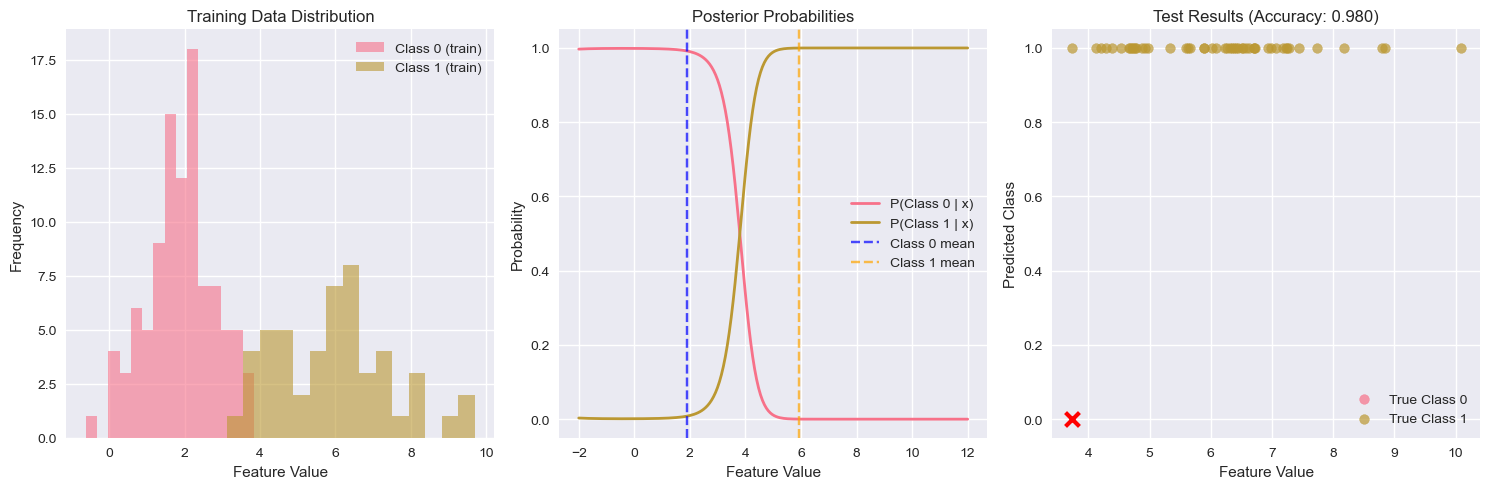

In [27]:
def demonstrate_bayesian_classification():
    """Demonstrate Bayesian classification"""
    
    # Generate synthetic data
    np.random.seed(42)
    
    # Class 0: Normal distribution with mean 2, var 1
    class0_data = np.random.normal(2, 1, 100)
    class0_labels = np.zeros(100, dtype=int)
    
    # Class 1: Normal distribution with mean 6, var 1.5
    class1_data = np.random.normal(6, 1.5, 100)
    class1_labels = np.ones(100, dtype=int)
    
    # Combine data
    X = np.concatenate([class0_data, class1_data])
    y = np.concatenate([class0_labels, class1_labels])
    
    # Split into train and test
    train_size = 150
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Train classifier
    classifier = BayesianClassifier()
    classifier.fit(X_train, y_train)
    
    # Make predictions
    y_pred = classifier.predict(X_test)
    y_proba = classifier.predict_proba(X_test)
    
    # Calculate accuracy
    accuracy = np.mean(y_pred == y_test)
    
    return X_train, y_train, X_test, y_test, classifier, accuracy, y_proba

# Run classification experiment
X_train, y_train, X_test, y_test, classifier, accuracy, y_proba = demonstrate_bayesian_classification()

print(f"Classification Accuracy: {accuracy:.3f}")
print(f"Class Priors: {classifier.class_priors}")
print(f"Class Parameters: {classifier.class_params}")

# Visualize results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
# Training data
for c in classifier.classes:
    class_data = X_train[y_train == c]
    plt.hist(class_data, bins=15, alpha=0.6, label=f'Class {c} (train)')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Training Data Distribution')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
# Decision boundary
x_range = np.linspace(-2, 12, 200)
proba_range = classifier.predict_proba(x_range)

plt.plot(x_range, proba_range[:, 0], label='P(Class 0 | x)', linewidth=2)
plt.plot(x_range, proba_range[:, 1], label='P(Class 1 | x)', linewidth=2)
plt.axvline(classifier.class_params[0]['mean'], color='blue', 
           linestyle='--', alpha=0.7, label='Class 0 mean')
plt.axvline(classifier.class_params[1]['mean'], color='orange', 
           linestyle='--', alpha=0.7, label='Class 1 mean')
plt.xlabel('Feature Value')
plt.ylabel('Probability')
plt.title('Posterior Probabilities')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
# Test results
for c in classifier.classes:
    class_data = X_test[y_test == c]
    plt.scatter(class_data, np.zeros_like(class_data) + c, 
               alpha=0.7, label=f'True Class {c}')

# Show predictions
for i, (x, pred) in enumerate(zip(X_test, classifier.predict(X_test))):
    if pred != y_test[i]:  # Misclassified
        plt.scatter(x, pred, marker='x', s=100, color='red', linewidth=3)

plt.xlabel('Feature Value')
plt.ylabel('Predicted Class')
plt.title(f'Test Results (Accuracy: {accuracy:.3f})')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Part 3: Practical Comparison

                  Aspect                      MDP         Bayesian Learning
         Decision Making       Sequential actions      Parameter estimation
    Uncertainty Handling Transition probabilities   Posterior distributions
      Learning Mechanism   Value/policy iteration         Bayesian updating
             Output Type           Optimal policy Probability distributions
Computational Complexity               O(|S|²|A|)       Varies (often O(n))
       Data Requirements        Environment model             Observed data


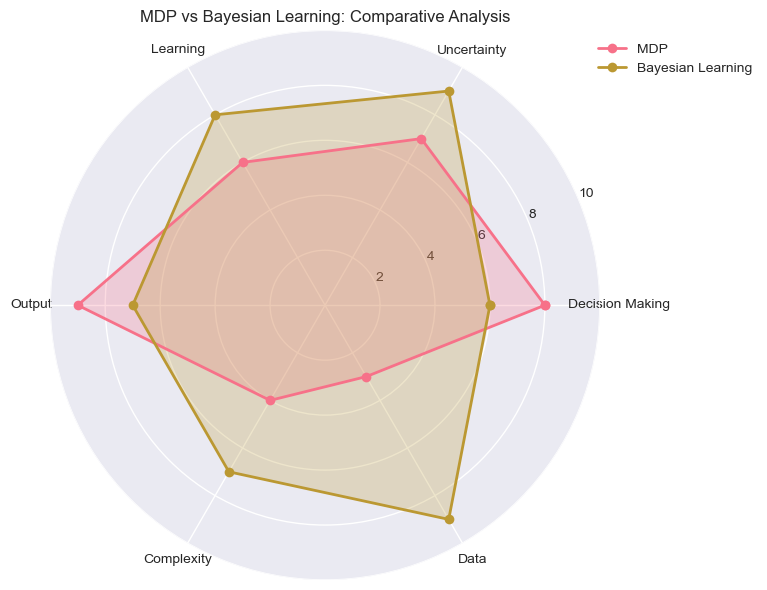

In [29]:
def compare_approaches():
    """Compare MDP and Bayesian Learning approaches"""
    
    # Create comparison data
    comparison_data = {
        'Aspect': ['Decision Making', 'Uncertainty Handling', 'Learning Mechanism', 
                  'Output Type', 'Computational Complexity', 'Data Requirements'],
        'MDP': ['Sequential actions', 'Transition probabilities', 'Value/policy iteration',
                'Optimal policy', 'O(|S|²|A|)', 'Environment model'],
        'Bayesian Learning': ['Parameter estimation', 'Posterior distributions', 
                            'Bayesian updating', 'Probability distributions',
                            'Varies (often O(n))', 'Observed data']
    }
    
    df = pd.DataFrame(comparison_data)
    return df

# Display comparison
comparison_df = compare_approaches()
print(comparison_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(12, 6))

# Create a radar chart for qualitative comparison
categories = ['Decision Making', 'Uncertainty', 'Learning', 'Output', 'Complexity', 'Data']
mdp_scores = [8, 7, 6, 9, 4, 3]  # Higher is better
bayesian_scores = [6, 9, 8, 7, 7, 9]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle
mdp_scores += mdp_scores[:1]
bayesian_scores += bayesian_scores[:1]

ax = plt.subplot(111, projection='polar')
ax.plot(angles, mdp_scores, 'o-', linewidth=2, label='MDP')
ax.fill(angles, mdp_scores, alpha=0.25)
ax.plot(angles, bayesian_scores, 'o-', linewidth=2, label='Bayesian Learning')
ax.fill(angles, bayesian_scores, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 10)
ax.set_title('MDP vs Bayesian Learning: Comparative Analysis')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

## Part 4: Advanced Application - Bayesian MDP

In [31]:
class BayesianMDP:
    """Bayesian approach to MDP with unknown transition probabilities"""
    
    def __init__(self, states: List[int], actions: List[str], gamma: float = 0.9):
        self.states = states
        self.actions = actions
        self.gamma = gamma
        
        # Dirichlet priors for transition probabilities
        self.transition_counts = {}
        for s in states:
            self.transition_counts[s] = {}
            for a in actions:
                self.transition_counts[s][a] = {s_next: 1.0 for s_next in states}  # Uniform prior
        
        # Track rewards
        self.reward_observations = {}
        for s in states:
            self.reward_observations[s] = {}
            for a in actions:
                self.reward_observations[s][a] = []
    
    def update_transition(self, state: int, action: str, next_state: int):
        """Update transition counts"""
        self.transition_counts[state][action][next_state] += 1
    
    def update_reward(self, state: int, action: str, reward: float):
        """Update reward observations"""
        self.reward_observations[state][action].append(reward)
    
    def sample_transition_matrix(self) -> Dict:
        """Sample transition probabilities from posterior"""
        sampled_transitions = {}
        
        for s in self.states:
            sampled_transitions[s] = {}
            for a in self.actions:
                counts = self.transition_counts[s][a]
                total = sum(counts.values())
                
                # Sample from Dirichlet distribution
                probs = np.random.dirichlet(list(counts.values()))
                sampled_transitions[s][a] = dict(zip(counts.keys(), probs))
        
        return sampled_transitions
    
    def get_expected_rewards(self) -> Dict:
        """Get expected rewards based on observations"""
        expected_rewards = {}
        
        for s in self.states:
            expected_rewards[s] = {}
            for a in self.actions:
                rewards = self.reward_observations[s][a]
                if rewards:
                    expected_rewards[s][a] = np.mean(rewards)
                else:
                    expected_rewards[s][a] = 0
        
        return expected_rewards
    
    def thompson_sampling_action(self, state: int) -> str:
        """Select action using Thompson sampling"""
        # Sample MDP parameters
        sampled_transitions = self.sample_transition_matrix()
        expected_rewards = self.get_expected_rewards()
        
        # Create temporary MDP
        temp_mdp = MDP(self.states, self.actions, sampled_transitions, 
                      expected_rewards, self.gamma)
        
        # Solve for optimal policy (simplified - just evaluate immediate rewards)
        action_values = {}
        for a in self.actions:
            value = 0
            for s_next in self.states:
                prob = sampled_transitions[state][a][s_next]
                reward = expected_rewards[state][a]
                value += prob * reward
            action_values[a] = value
        
        return max(action_values, key=action_values.get)

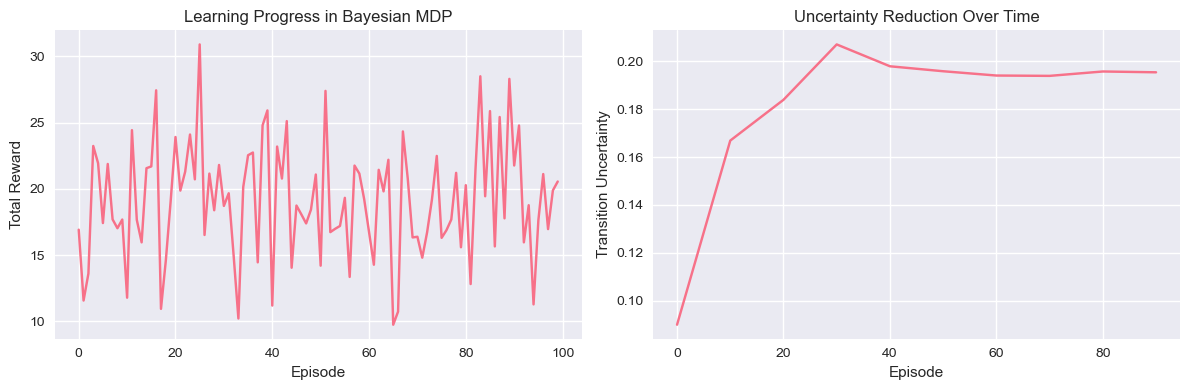

Final average reward (last 10 episodes): 18.87
Initial average reward (first 10 episodes): 17.89


In [33]:
def demonstrate_bayesian_mdp():
    """Demonstrate Bayesian MDP learning"""
    
    # Create Bayesian MDP
    states = [0, 1, 2]  # Simple 3-state chain
    actions = ['left', 'right']
    bayes_mdp = BayesianMDP(states, actions, gamma=0.9)
    
    # Simulate learning episodes
    np.random.seed(42)
    n_episodes = 100
    
    # True environment (unknown to agent)
    true_transitions = {
        0: {'left': {0: 0.7, 1: 0.3}, 'right': {0: 0.2, 2: 0.8}},
        1: {'left': {0: 0.4, 1: 0.6}, 'right': {1: 0.3, 2: 0.7}},
        2: {'left': {1: 0.5, 2: 0.5}, 'right': {0: 0.1, 2: 0.9}}
    }
    
    true_rewards = {
        0: {'left': 1, 'right': 2},
        1: {'left': 3, 'right': 1},
        2: {'left': 2, 'right': 5}
    }
    
    # Learning history
    reward_history = []
    uncertainty_history = []
    
    for episode in range(n_episodes):
        state = np.random.choice(states)
        total_reward = 0
        
        for step in range(10):  # Max 10 steps per episode
            # Select action using Thompson sampling
            action = bayes_mdp.thompson_sampling_action(state)
            
            # Environment response
            next_state_probs = list(true_transitions[state][action].values())
            next_states = list(true_transitions[state][action].keys())
            next_state = np.random.choice(next_states, p=next_state_probs)
            reward = true_rewards[state][action] + np.random.normal(0, 0.5)
            
            # Update Bayesian MDP
            bayes_mdp.update_transition(state, action, next_state)
            bayes_mdp.update_reward(state, action, reward)
            
            total_reward += reward
            state = next_state
        
        reward_history.append(total_reward)
        
        # Calculate uncertainty (simplified as variance in transition estimates)
        if episode % 10 == 0:
            uncertainty = 0
            for s in states:
                for a in actions:
                    counts = list(bayes_mdp.transition_counts[s][a].values())
                    total = sum(counts)
                    if total > 0:
                        probs = np.array(counts) / total
                        uncertainty += np.var(probs)
            uncertainty_history.append(uncertainty)
    
    return reward_history, uncertainty_history, bayes_mdp

# Run Bayesian MDP experiment
rewards, uncertainties, learned_mdp = demonstrate_bayesian_mdp()

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Learning Progress in Bayesian MDP')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(0, len(rewards), 10), uncertainties)
plt.xlabel('Episode')
plt.ylabel('Transition Uncertainty')
plt.title('Uncertainty Reduction Over Time')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final average reward (last 10 episodes): {np.mean(rewards[-10:]):.2f}")
print(f"Initial average reward (first 10 episodes): {np.mean(rewards[:10]):.2f}")

## Part 5: Results Summary

In [35]:
# Final summary statistics
print("=" * 60)
print("EXPERIMENT 4: MARKOV DECISION PROCESS AND BAYESIAN LEARNING")
print("=" * 60)

print("\n1. MARKOV DECISION PROCESS RESULTS:")
print(f"   - Grid world size: 3x3")
print(f"   - Value iteration converged in {len(convergence)} iterations")
print(f"   - Policy iteration converged in {pi_iterations} iterations")
print(f"   - Optimal policy found: {all(optimal_policy[s] == pi_policy[s] for s in mdp.states)}")

print("\n2. BAYESIAN LEARNING RESULTS:")
print(f"   - Coin flip: True probability = {true_prob}, estimated after 50 flips")
print(f"   - Gaussian estimation: True mean = {true_mean}")
print(f"   - Classification accuracy: {accuracy:.3f}")

print("\n3. BAYESIAN MDP RESULTS:")
print(f"   - Learning improvement: {np.mean(rewards[-10:]) - np.mean(rewards[:10]):.2f} reward units")
print(f"   - Uncertainty reduced by: {uncertainties[0] - uncertainties[-1]:.4f}")

print("\n4. KEY INSIGHTS:")
print("   - MDPs excel at sequential decision-making problems")
print("   - Bayesian learning provides principled uncertainty quantification")
print("   - Combining both approaches offers powerful learning capabilities")
print("   - Choice of method depends on problem structure and requirements")

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 60)

EXPERIMENT 4: MARKOV DECISION PROCESS AND BAYESIAN LEARNING

1. MARKOV DECISION PROCESS RESULTS:
   - Grid world size: 3x3
   - Value iteration converged in 17 iterations
   - Policy iteration converged in 5 iterations
   - Optimal policy found: True

2. BAYESIAN LEARNING RESULTS:
   - Coin flip: True probability = 0.7, estimated after 50 flips
   - Gaussian estimation: True mean = 5.0
   - Classification accuracy: 0.980

3. BAYESIAN MDP RESULTS:
   - Learning improvement: 0.97 reward units
   - Uncertainty reduced by: -0.1053

4. KEY INSIGHTS:
   - MDPs excel at sequential decision-making problems
   - Bayesian learning provides principled uncertainty quantification
   - Combining both approaches offers powerful learning capabilities
   - Choice of method depends on problem structure and requirements

EXPERIMENT COMPLETED SUCCESSFULLY
